# Data Loading

In [307]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("camnugent/california-housing-prices")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\ASUS\.cache\kagglehub\datasets\camnugent\california-housing-prices\versions\1


In [308]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import sklearn
import warnings
warnings.filterwarnings('ignore')


In [309]:
df = pd.read_csv(path + "/housing.csv")

In [310]:
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


# EDA

In [311]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.6 MB


In [312]:
df['ocean_proximity'].value_counts()

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

In [313]:
df.isna().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

In [314]:
df1 = df.copy()
df1['total_bedrooms'] = df1['total_bedrooms'].fillna(df1['total_bedrooms'].median())

In [315]:
df1


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY
...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND


In [316]:
df1.isna().sum()

longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
ocean_proximity       0
dtype: int64

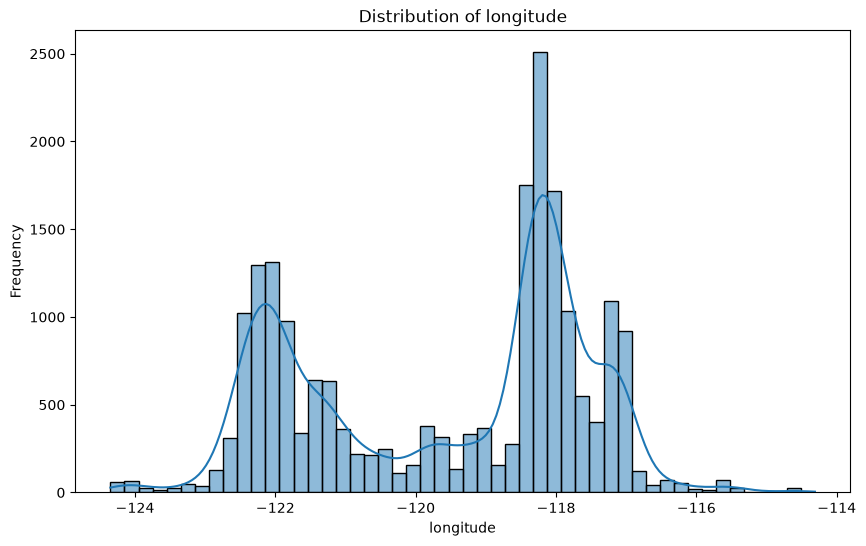

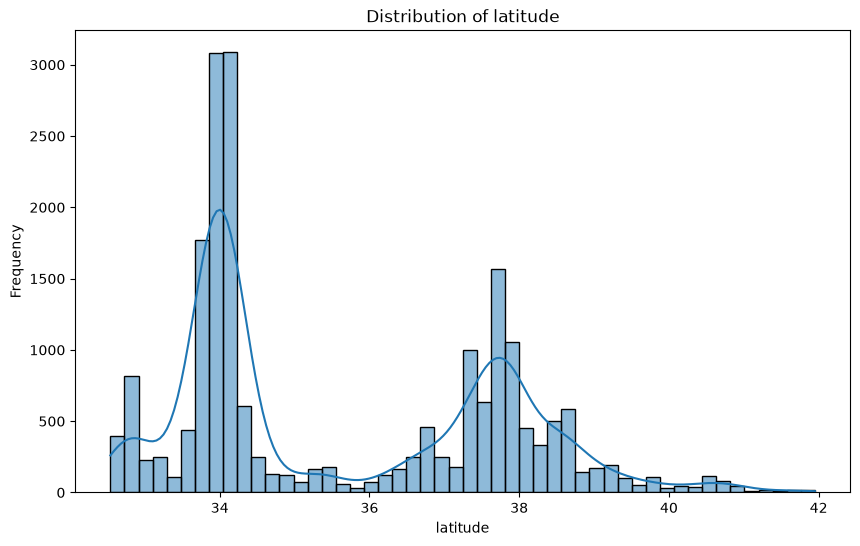

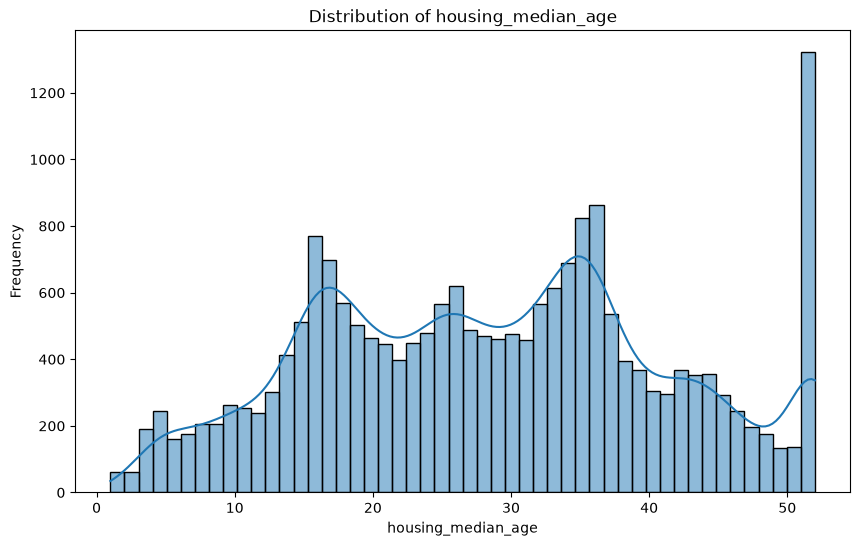

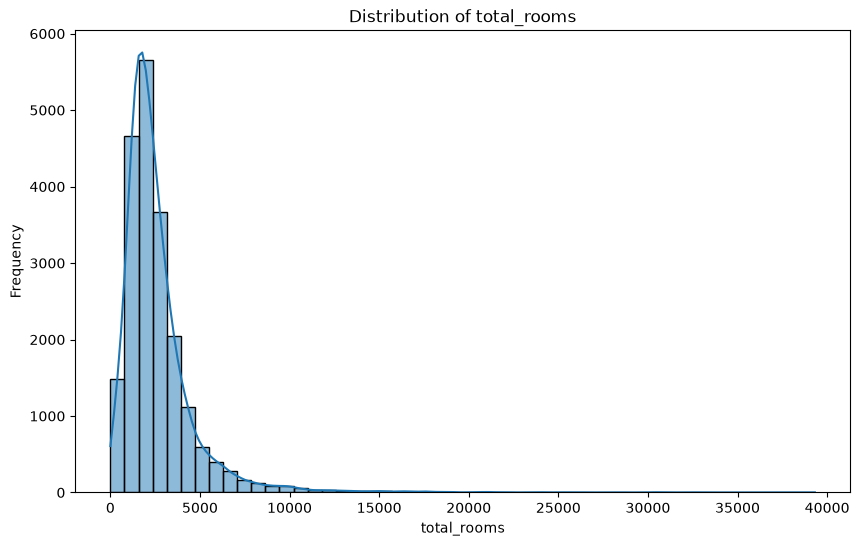

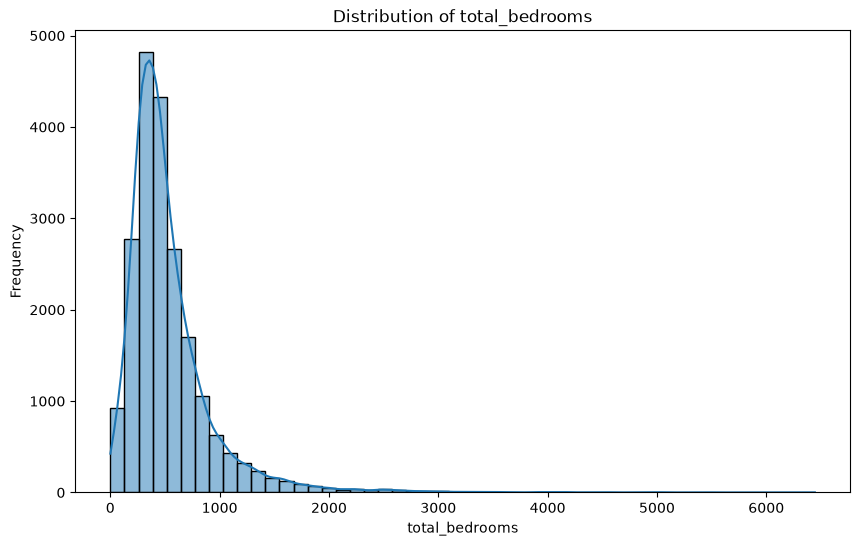

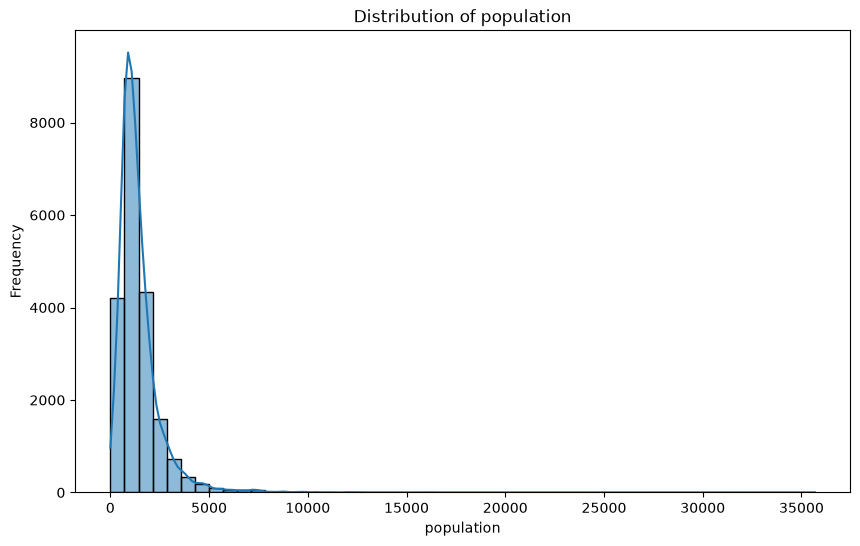

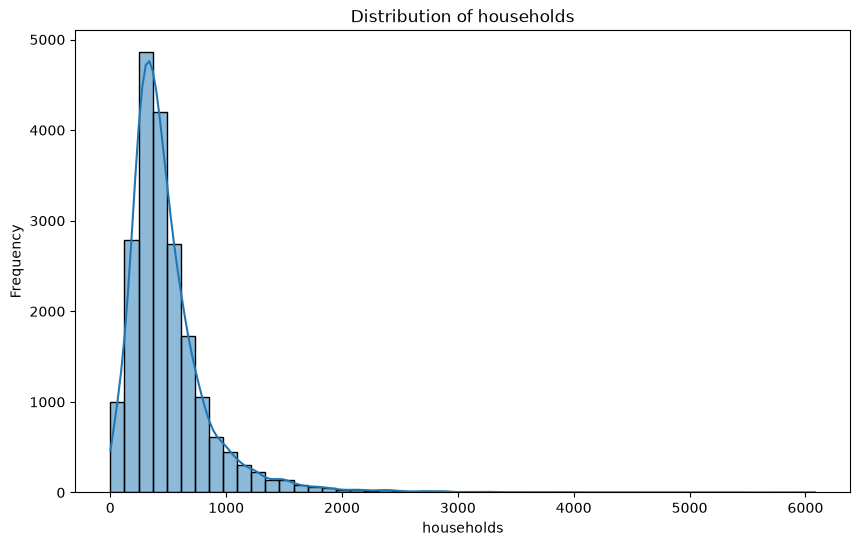

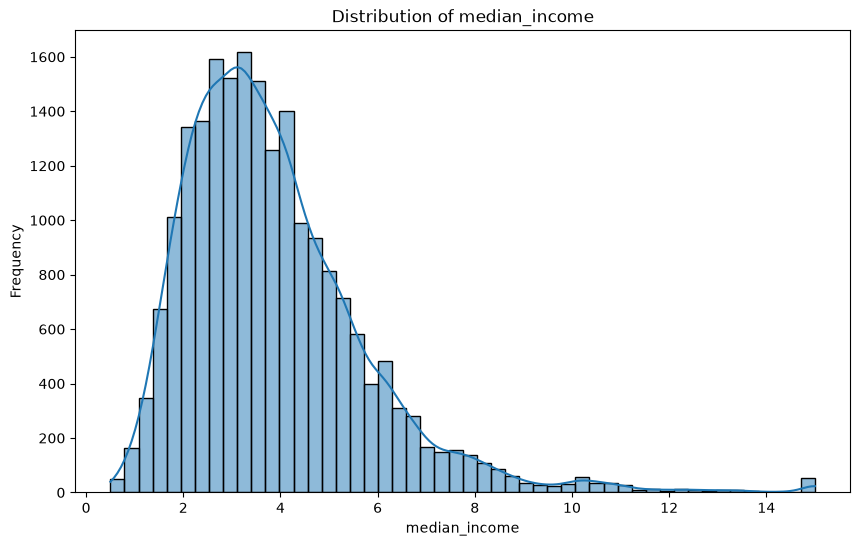

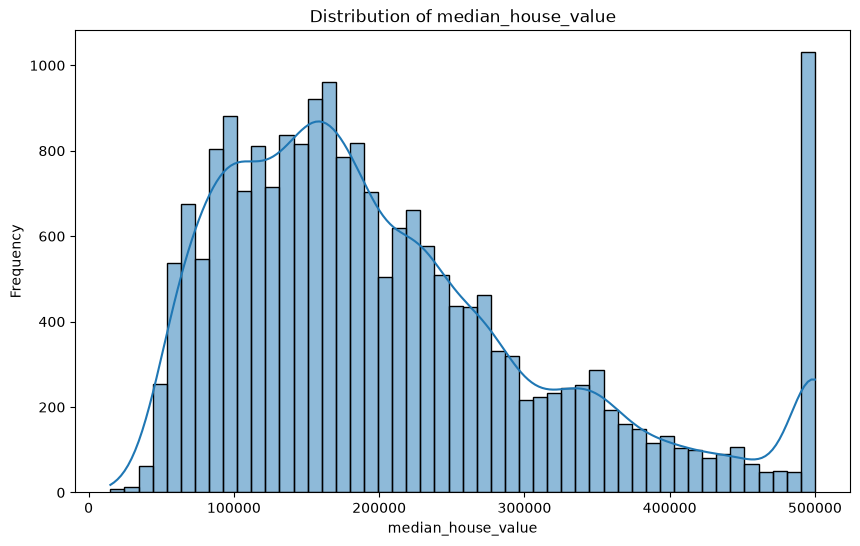

In [317]:
numerical_cols = df1.select_dtypes(include=[np.number]).columns.tolist()
for col in numerical_cols:
    plt.figure(figsize=(10, 6))
    sns.histplot(df1[col], bins=50, kde=True)
    plt.xlabel('' + col)
    plt.ylabel('Frequency')
    plt.title(f'Distribution of {col}')
    plt.show()

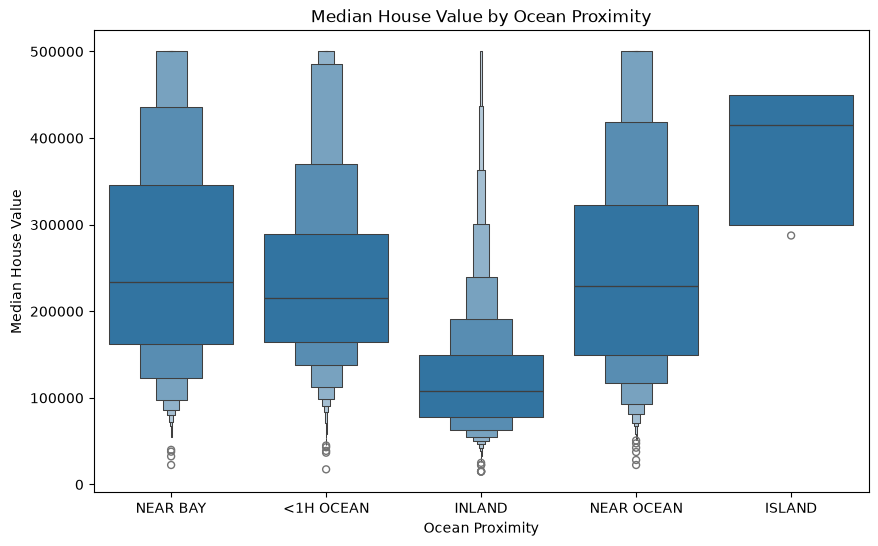

In [318]:
plt.figure(figsize=(10, 6))
sns.boxenplot(x='ocean_proximity', y='median_house_value', data=df1)
plt.xlabel('Ocean Proximity')
plt.ylabel('Median House Value')
plt.title('Median House Value by Ocean Proximity')
plt.show()



In [319]:
df1.columns

Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value', 'ocean_proximity'],
      dtype='str')

<Axes: >

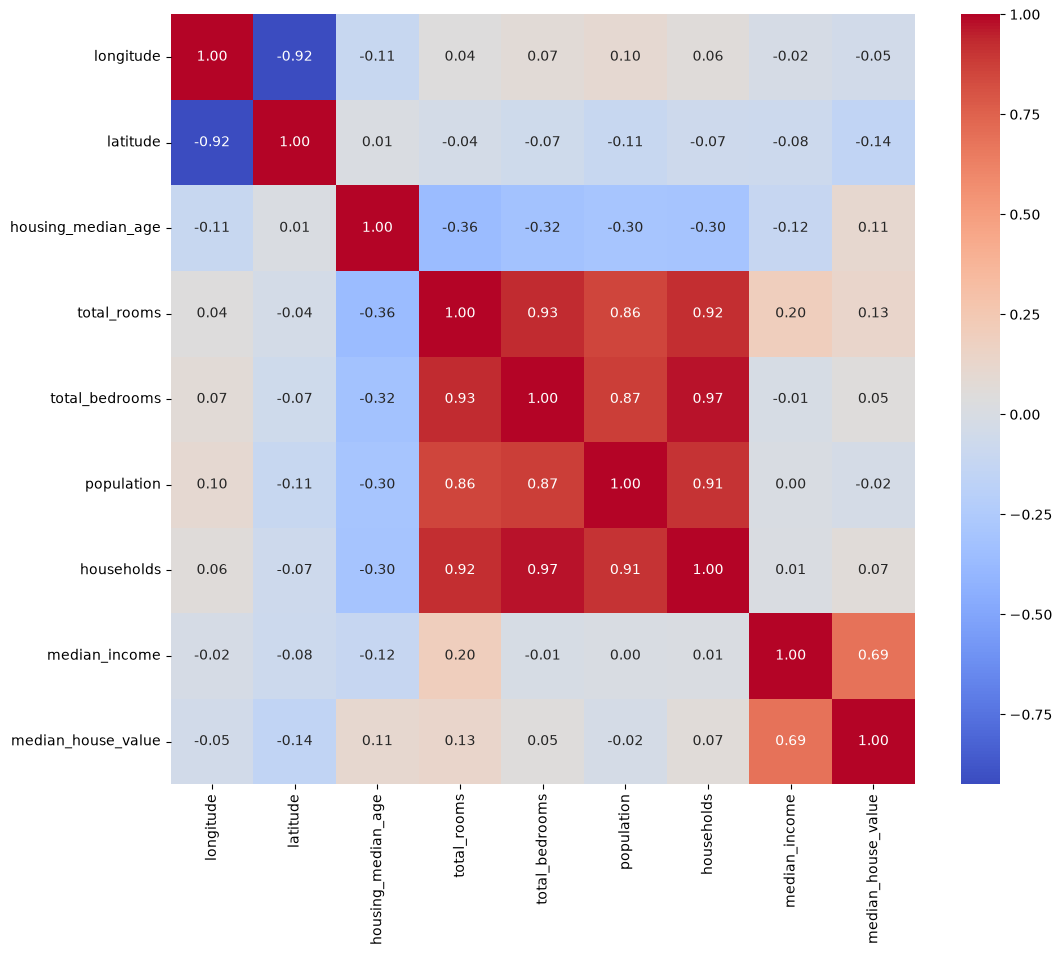

In [320]:
numerical_cols = df1.select_dtypes(include=[np.number]).columns.tolist()
plt.figure(figsize=(12, 10))
sns.heatmap(df1[numerical_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f")

<Axes: xlabel='median_house_value', ylabel='total_rooms'>

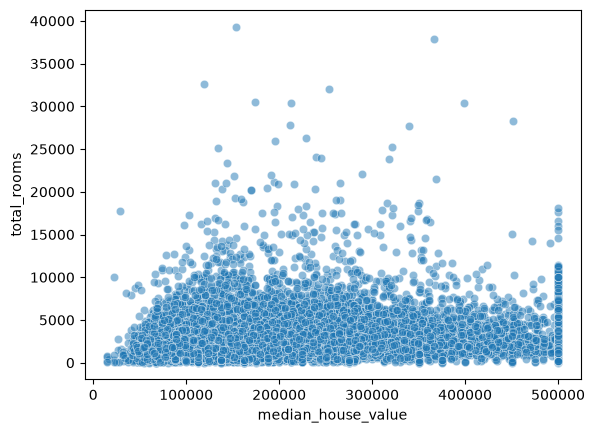

In [321]:
sns.scatterplot(y='total_rooms', x='median_house_value',data=df1, palette='viridis', alpha=0.5)

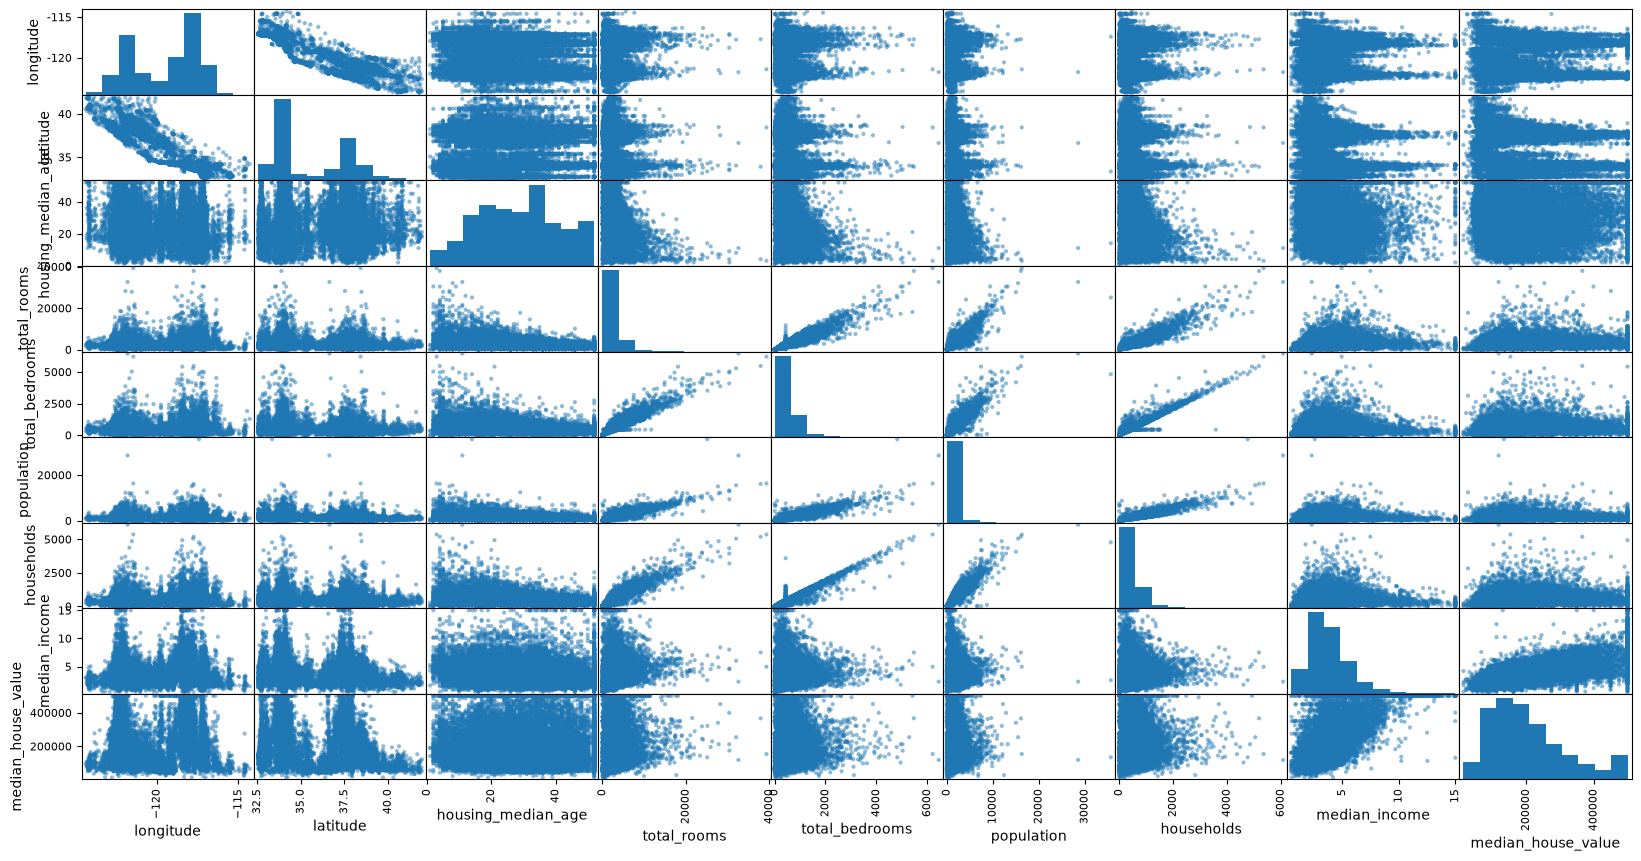

In [322]:
from pandas.plotting import scatter_matrix
import matplotlib.pyplot as plt

# Generate the scatter matrix
scatter_matrix(df1, figsize=(20, 10))

# Display the plot
plt.show()


# Removing capped target values

The census capped `median_house_value` at \$500,001, so the ~965 districts at that value are censored labels (their true value is \$500k or more), not real prices. We drop them so the model doesn't learn a false ceiling. Note: the resulting model is only valid for districts under \$500k.

In [323]:
capped = df1['median_house_value'] >= 500001
print(f"Dropping {capped.sum()} capped rows ({capped.mean():.1%} of the data)")
df1 = df1[~capped].reset_index(drop=True)
df1.shape

Dropping 965 capped rows (4.7% of the data)


(19675, 10)

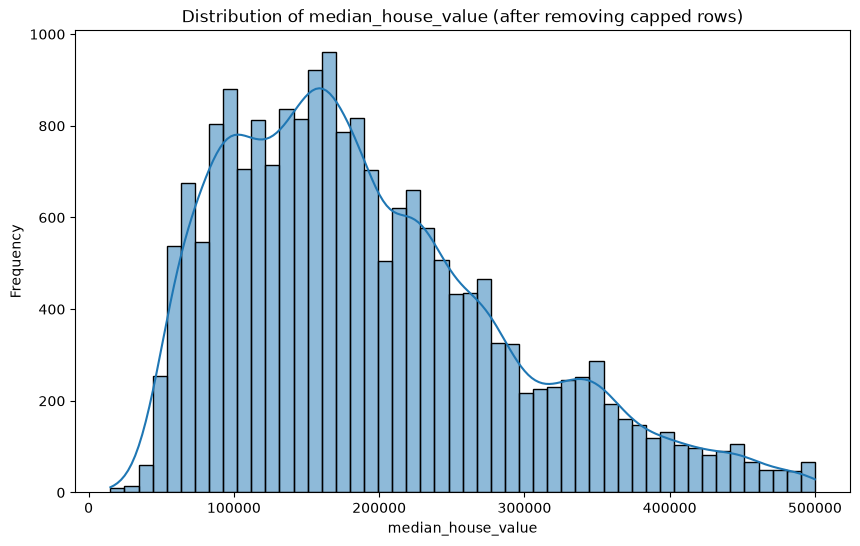

In [324]:
plt.figure(figsize=(10, 6))
sns.histplot(df1['median_house_value'], bins=50, kde=True)
plt.ylabel('Frequency')
plt.title('Distribution of median_house_value (after removing capped rows)')
plt.show()

In [325]:
df1['population'].min(), (df1['population'] == 0).sum()



(np.float64(3.0), np.int64(0))

<Axes: xlabel='population', ylabel='Count'>

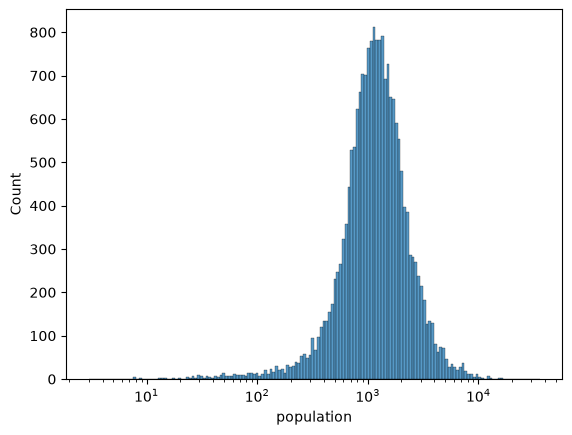

In [326]:
sns.histplot(df1['population'], log_scale=True)


# Data Preprocessing 

In [327]:
X = df1.drop(columns=['median_house_value'])
y = df1['median_house_value']

In [328]:
X.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,NEAR BAY


In [329]:
X['ocean_proximity'].value_counts()

ocean_proximity
<1H OCEAN     8604
INLAND        6524
NEAR OCEAN    2446
NEAR BAY      2096
ISLAND           5
Name: count, dtype: int64

In [330]:
X_encoded = pd.get_dummies(X, columns=['ocean_proximity'], drop_first=True, dtype=int)
X_encoded.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,0,0,1,0
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,0,0,1,0
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,0,0,1,0
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,0,0,1,0
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,0,0,1,0


In [331]:
X_encoded['ocean_proximity_NEAR BAY'].value_counts()

ocean_proximity_NEAR BAY
0    17579
1     2096
Name: count, dtype: int64

In [332]:
from sklearn.preprocessing import LabelEncoder
X_lable = X.copy()
le = LabelEncoder()
X_lable['ocean_proximity'] = le.fit_transform(X_lable['ocean_proximity'])
X_lable.head()


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,3
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,3
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,3
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,3
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,3


In [333]:
from sklearn.preprocessing import StandardScaler
num_cols = ['longitude',
 'latitude',
 'housing_median_age',
 'total_rooms',
 'total_bedrooms',
 'population',
 'households',
 'median_income']

scaler = StandardScaler()
X_encoded[num_cols] = scaler.fit_transform(X_encoded[num_cols])


X_encoded

In [334]:
X_encoded.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
0,-1.329378,1.036503,1.008388,-0.797584,-0.974311,-0.978308,-0.978946,2.960380,0,0,1,0
1,-1.324393,1.027200,-0.590487,2.053478,1.349771,0.839604,1.661594,2.945223,0,0,1,0
2,-1.334362,1.022548,1.887770,-0.528477,-0.829205,-0.826159,-0.845876,2.280353,0,0,1,0
3,-1.339347,1.022548,1.887770,-0.616957,-0.722159,-0.771946,-0.736288,1.252288,0,0,1,0
4,-1.339347,1.022548,1.887770,-0.455126,-0.615113,-0.765825,-0.631919,0.107935,0,0,1,0


X_lable

In [335]:
X_lable.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,3
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,3
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,3
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,3
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,3


In [336]:
X_lable.columns

Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'ocean_proximity'],
      dtype='str')

In [337]:
scaler = StandardScaler()
num_cols_L = ['longitude', 'latitude', 'housing_median_age', 'total_rooms','total_bedrooms', 'population', 'households', 'median_income']
X_lable[num_cols_L] = scaler.fit_transform(X_lable[num_cols_L])

# One Hot Encoded Model

In [338]:
from sklearn.model_selection import train_test_split
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, r2_score, mean_squared_error
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42)

In [339]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](12,)","[-48522.29,-48092.47, 11425.23,...,184740.92, -8571.35, 3551.4 ]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](12,)","['longitude','latitude','housing_median_age',...,'ocean_proximity_ISLAND', 'ocean_proximity_NEAR BAY','ocean_proximity_NEAR OCEAN']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,2.06e+05
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,12
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(12)


In [340]:
y_pred = model.predict(X_test)
y_pred

array([155074.65256417, 213318.56423554, 177824.11909305, ...,
       129965.45296634, 146076.87325567, 243414.07262402], shape=(3935,))

In [341]:

r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

print("R² Score:", r2)
print("MSE:", mse)

R² Score: 0.607457457139063
MSE: 3914036126.808652


# Lable Encoding Model 


In [342]:
X_lable.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity
0,-1.329378,1.036503,1.008388,-0.797584,-0.974311,-0.978308,-0.978946,2.960380,3
1,-1.324393,1.027200,-0.590487,2.053478,1.349771,0.839604,1.661594,2.945223,3
2,-1.334362,1.022548,1.887770,-0.528477,-0.829205,-0.826159,-0.845876,2.280353,3
3,-1.339347,1.022548,1.887770,-0.616957,-0.722159,-0.771946,-0.736288,1.252288,3
4,-1.339347,1.022548,1.887770,-0.455126,-0.615113,-0.765825,-0.631919,0.107935,3


In [343]:
from sklearn.model_selection import train_test_split
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, r2_score, mean_squared_error
X_train, X_test, y_train, y_test = train_test_split(X_lable, y, test_size=0.25, random_state=20)

In [344]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](9,)","[-78906.58,-83505.96, 12660.93,..., 27251.9 , 61966.87, 81.18]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](9,)","['longitude','latitude','housing_median_age',...,'households', 'median_income','ocean_proximity']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,1.922e+05
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,9
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(9)


In [345]:
y_pred = model.predict(X_test)
y_pred

array([298470.03829968, 144709.31756065, 205851.14034138, ...,
       244921.9435888 , 116752.56599335, 145253.55240227], shape=(4919,))

In [346]:

r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

print("R² Score:", r2)
print("MSE:", mse)

R² Score: 0.5939396013218725
MSE: 3814130067.273569


# Ridge

Ridge is linear regression with L2 regularization: it adds a penalty `alpha * sum(coef²)` that shrinks the coefficients toward zero. It helps when a model **overfits** (train score much higher than test score) or when features are strongly correlated. With ~19.7k rows and only 12 features, plain LinearRegression barely overfits here — so Ridge should score about the same (~0.61). Regularization cannot fix *underfitting*, which is what limits the linear model on this dataset.

In [347]:
from sklearn.linear_model import Ridge

# re-split from X_encoded so we compare against the one-hot model on the same split
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42)

ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)

y_pred_ridge = ridge.predict(X_test)

r2 = r2_score(y_test, y_pred_ridge)
mse = mean_squared_error(y_test, y_pred_ridge)
print("R² Score:", r2)
print("MSE:", mse)

R² Score: 0.6075870449821423
MSE: 3912744008.2634587


In [348]:
from sklearn.linear_model import RidgeCV

# let cross-validation pick the best alpha
alphas = [0.01, 0.1, 1, 10, 100, 1000]
ridge_cv = RidgeCV(alphas=alphas, cv=5)
ridge_cv.fit(X_train, y_train)
print("Best alpha:", ridge_cv.alpha_)

y_pred_cv = ridge_cv.predict(X_test)
print("R² Score:", r2_score(y_test, y_pred_cv))
print("MSE:", mean_squared_error(y_test, y_pred_cv))

Best alpha: 0.01
R² Score: 0.6074594821085473
MSE: 3914015935.8666463


# Lasso

Lasso is linear regression with **L1** regularization: the penalty `alpha * sum(|coef|)` can shrink coefficients to **exactly zero**, so unlike Ridge it also does feature selection. Same expectation as Ridge here: our linear model underfits, so Lasso won't beat plain LinearRegression (~0.61) — but it's useful for seeing which features the model considers dispensable as the penalty grows.

In [349]:
from sklearn.linear_model import Lasso

# same split as the Ridge / one-hot models for a fair comparison
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42)

lasso = Lasso(alpha=1.0)
lasso.fit(X_train, y_train)

y_pred_lasso = lasso.predict(X_test)

r2 = r2_score(y_test, y_pred_lasso)
mse = mean_squared_error(y_test, y_pred_lasso)
print("R² Score:", r2)
print("MSE:", mse)
print("Coefficients set to zero:", (lasso.coef_ == 0).sum(), "of", len(lasso.coef_))

R² Score: 0.6074756222461374
MSE: 3913855002.783677
Coefficients set to zero: 0 of 12


In [350]:
from sklearn.linear_model import LassoCV

# let cross-validation pick the best alpha
alphas = [0.01, 0.1, 1, 10, 100, 1000]
lasso_cv = LassoCV(alphas=alphas, cv=5, random_state=42)
lasso_cv.fit(X_train, y_train)
print("Best alpha:", lasso_cv.alpha_)

y_pred_cv = lasso_cv.predict(X_test)
print("R² Score:", r2_score(y_test, y_pred_cv))
print("MSE:", mean_squared_error(y_test, y_pred_cv))

Best alpha: 0.01
R² Score: 0.6074576437484627
MSE: 3914034266.128975


In [351]:
# Lasso's feature selection in action: crank up alpha and see which features get dropped
lasso_strong = Lasso(alpha=1000)
lasso_strong.fit(X_train, y_train)

coefs = pd.Series(lasso_strong.coef_, index=X_encoded.columns).sort_values(key=abs, ascending=False)
print(coefs.round(1))
print("\nDropped features:", list(coefs[coefs == 0].index))
print("R² Score:", r2_score(y_test, lasso_strong.predict(X_test)))

median_income                 56027.7
ocean_proximity_INLAND       -50378.4
population                   -28958.2
longitude                    -27300.1
latitude                     -26967.1
households                    20580.5
total_bedrooms                13167.4
housing_median_age            10681.6
ocean_proximity_NEAR OCEAN      118.8
total_rooms                      -0.0
ocean_proximity_ISLAND            0.0
ocean_proximity_NEAR BAY         -0.0
dtype: float64

Dropped features: ['total_rooms', 'ocean_proximity_ISLAND', 'ocean_proximity_NEAR BAY']
R² Score: 0.6020692588462462


# Pipeline Workflow: Feature Engineering + Preprocessing

This section redoes preprocessing the production-grade sklearn way, with three improvements over the earlier `X_encoded` / `X_lable` approach:

1. **Split first, transform after** — the scaler/imputer/encoder are fit on the *training set only* and applied to the test set. Earlier we fit the scaler on all data before splitting, which leaks test-set statistics into training.
2. **Custom transformer** (`HousingFeatureEngineer`) adds ratio features like `rooms_per_household` — these describe housing *quality* instead of district *size*, which raw counts like `total_rooms` mostly measure.
3. **Everything in one `ColumnTransformer`** — numeric and categorical columns each get their own pipeline, and the whole thing can be reused on new data with a single `.transform()` call (`handle_unknown="ignore"` keeps it from crashing on unseen categories).

In [352]:
from sklearn.base import BaseEstimator, TransformerMixin

class HousingFeatureEngineer(BaseEstimator, TransformerMixin):

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()

        # NaN-safe denominators — any NaN produced here is filled by the
        # SimpleImputer that runs right after this transformer in num_pipeline
        households_safe = X['households'].replace(0, np.nan)
        rooms_safe = X['total_rooms'].replace(0, np.nan)
        population_safe = X['population'].replace(0, np.nan)

        # Ratio-based features
        X['rooms_per_household'] = X['total_rooms'] / households_safe
        X['bedrooms_per_room'] = X['total_bedrooms'] / rooms_safe
        X['bedrooms_per_household'] = X['total_bedrooms'] / households_safe
        X['population_per_household'] = X['population'] / households_safe
        X['rooms_per_person'] = X['total_rooms'] / population_safe

        # Income-density features
        X['income_per_household_member'] = X['median_income'] / X['population_per_household']
        X['income_x_rooms_per_household'] = X['median_income'] * X['rooms_per_household']

        # Geographic interaction features
        X['lat_x_lon'] = X['latitude'] * X['longitude']
        X['lat_plus_lon'] = X['latitude'] + X['longitude']

        # Log-transform skewed count features
        for col in ['total_rooms', 'total_bedrooms', 'population', 'households']:
            X[f'log_{col}'] = np.log1p(X[col])

        return X

In [353]:
# split the RAW data first — all preprocessing below is fit on the training set only
X_train, X_test, y_train, y_test = train_test_split(
    df1.drop('median_house_value', axis=1),
    df1['median_house_value'],
    test_size=0.2,
    random_state=42
)
X_train.shape, X_test.shape

((15740, 9), (3935, 9))

In [354]:
from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import PowerTransformer, OneHotEncoder

num_cols = X_train.select_dtypes(np.number).columns
# note: exclude=np.number instead of select_dtypes('object') — in pandas 3 the
# text column has dtype 'str', and selecting 'object' is deprecated for it
cat_cols = X_train.select_dtypes(exclude=np.number).columns

print(f"Numeric features: {len(num_cols)}")
print(f"Categorical features: {len(cat_cols)}")
print("Categorical columns:", list(cat_cols))

feature_engineering = HousingFeatureEngineer()

num_pipeline = make_pipeline(
    feature_engineering,
    SimpleImputer(strategy='median'),
    PowerTransformer()
)

cat_pipeline = make_pipeline(
    SimpleImputer(strategy="most_frequent"),
    OneHotEncoder(handle_unknown="ignore")
)

Numeric features: 8
Categorical features: 1
Categorical columns: ['ocean_proximity']


In [355]:
from sklearn.compose import ColumnTransformer

preprocessing = ColumnTransformer([
    ('num', num_pipeline, num_cols),
    ('cat', cat_pipeline, cat_cols)
])

X_train = preprocessing.fit_transform(X_train)   # fit on train only
X_test = preprocessing.transform(X_test)         # apply the SAME fitted transforms to test

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)


X_train: (15740, 26)
X_test: (3935, 26)


# Random Forest

Every linear variant (plain, Ridge, Lasso) plateaued at R² ≈ 0.61–0.65 because a linear model can only fit straight-line effects — it cannot express "SF and LA are expensive but the Central Valley between them is cheap." Tree ensembles split the feature space into regions instead, so they capture exactly the geographic and interaction structure this dataset is full of. Same pipeline features, different model class.

In [357]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

r2 = r2_score(y_test, y_pred_rf)
mse = mean_squared_error(y_test, y_pred_rf)
print("R² Score:", r2)
print("MSE:", mse)
print("RMSE:", round(np.sqrt(mse)))

R² Score: 0.8021442971171773
MSE: 1972816406.9412286
RMSE: 44416


# Conclusion

**Linear Regression cannot reach 75–80% on this dataset — Random Forest is the right model.**

| Model | R² Score |
|---|---|
| Linear Regression (baseline) | 0.61 |
| Ridge / Lasso (tuned alpha) | 0.61 |
| Linear Regression + feature engineering pipeline | 0.65 |
| **Random Forest (same features)** | **0.80** |

Key takeaways:

1. Linear Regression plateaus at R² ≈ 0.61–0.65 no matter what we do — bug fixes, scaling, Ridge/Lasso regularization, and heavy feature engineering all failed to push it near 0.75. The reason: the relationship between the features and house price is **not linear**, especially geography (SF and LA are expensive while the Central Valley between them is cheap — no straight line can describe that).
2. Ridge and Lasso gave zero improvement because regularization fixes *overfitting*, and our linear model was *underfitting*.
3. Random Forest on the **same pipeline features** jumps to R² = 0.80 and cuts the average prediction error from about \$63k to \$44k. The model class was the bottleneck, not the data preparation.
4. Note: R² is not "accuracy" — 0.80 means the model explains 80% of the variance in house prices. Since the dataset lacks factors like school quality, crime, and house condition, ~0.85 is roughly the practical ceiling for any model here.